In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [4]:
url ='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/refs/heads/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
data = !wget $url

In [8]:
data

['--2026-09-30 15:43:43--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/refs/heads/main/cohorts/2026/data/car_fuel_efficiency_2026.csv',
 'Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...',
 'Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.',
 'HTTP request sent, awaiting response... 200 OK',
 'Length: 635180 (620K) [text/plain]',
 'Saving to: ‘car_fuel_efficiency_2026.csv’',
 '',
 '     0K .......... .......... .......... .......... ..........  8% 26.4M 0s',
 '    50K .......... .......... .......... .......... .......... 16% 30.6M 0s',
 '   100K .......... .......... .......... .......... .......... 24%  182M 0s',
 '   150K .......... .......... .......... .......... .......... 32%  186M 0s',
 '   200K .......... .......... .......... .......... .......... 40% 39.4M 0s',
 '   250K .......... .......... .......... .......... ......

In [9]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')

In [10]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [13]:
df.columns = df.columns.str.lower().str.replace(' ' , '_')

In [15]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [14]:
Strings = list(df.dtypes[df.dtypes == 'str'].index)
Strings

['origin', 'fuel_type', 'drivetrain']

In [11]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight','model_year', 'fuel_efficiency_mpg']

In [16]:
df_base = df[base]

In [17]:
df_base

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

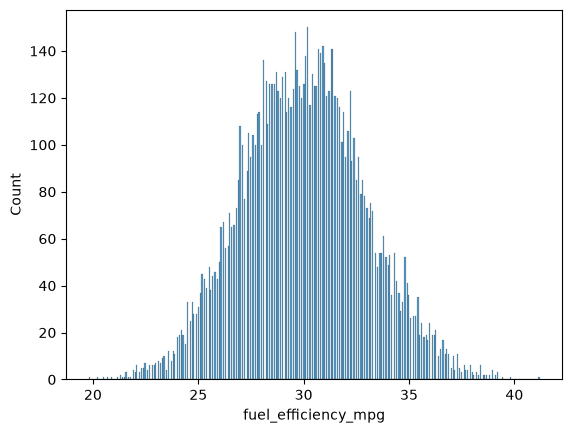

In [27]:
sns.histplot(df_base.fuel_efficiency_mpg, bins = 380)

In [30]:
df_base.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [33]:
median_hp = df_base['horsepower'].median()
print(median_hp)

254.0


In [34]:
n = len(df_base)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_base.iloc[idx[:n_train]]
df_val = df_base.iloc[idx[n_train:n_train + n_val]]
df_test = df_base.iloc[idx[n_train + n_val:]]

In [37]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [74]:
y_train

array([32.5, 29.1, 34.1, ..., 27.7, 31.6, 28. ], shape=(6000,))

In [60]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [61]:
def fill_hp_0(df):
    df_fill = df.copy()
    df_fill['horsepower'].fillna(0)
    return df_fill

In [62]:
def fill_hp_med(df):
    df_fill = df.copy()
    df_fill['horsepower'].fillna(df_train['horsepower'].median())
    return df_fill
    

In [63]:
def prepare_X(df):
    df_num = df.copy()
    X = df_num.values
    return X

In [71]:
def train_linear_regression(X , y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones , X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)

    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0],w_full[1:]

In [65]:
#trainning the first model after filling the missing values in horsepower with zeros

In [66]:
df_train_0 = fill_hp_0(df_train)

In [67]:
X_train_0 = prepare_X(df_train_0)

In [68]:
X_train_0

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [69]:
df_train_0

,engine_displacement,horsepower,vehicle_weight,model_year
6252,1900,239.0,3790,2015
4684,2000,224.0,4380,1992
1731,2330,286.0,4090,2022
4742,2300,NaN,4150,1997
4521,2340,269.0,4400,2001
...,...,...,...,...
7895,2280,242.0,4590,2018
9590,2300,NaN,4240,1984
7288,2240,255.0,4190,1989
278,2430,254.0,4280,2020


In [72]:
w0_0, w_0 = train_linear_regression(X_train_0 , y_train)

In [73]:
print(w0_0)
w_0

nan


array([nan, nan, nan, nan])